In [ ]:
import torch
from torch import nn
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.datasets import make_circles #Make circles is a binary classification dataset inbuilt in sklearn

In [ ]:
import requests
from pathlib import Path
path = Path('helper_functions.py')
link = 'https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py'

if path.exists():
  print('Path exists')
else:
  print('Downloading it ')
  request = requests.get(link)
  with open('helper_function.py','wb') as file:
    file.write(request.content)
  print('Downloaded')


Downloaded


In [ ]:
from helper_function import plot_decision_boundary

## 6. The missing piece: non-linearity

We've seen our model can draw straight (linear) lines, thanks to its linear layers.

But how about we give it the capacity to draw non-straight (non-linear) lines?

How?

Let's find out.


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [ ]:
X,y = make_circles(n_samples=1000,noise=0.03,random_state=42)

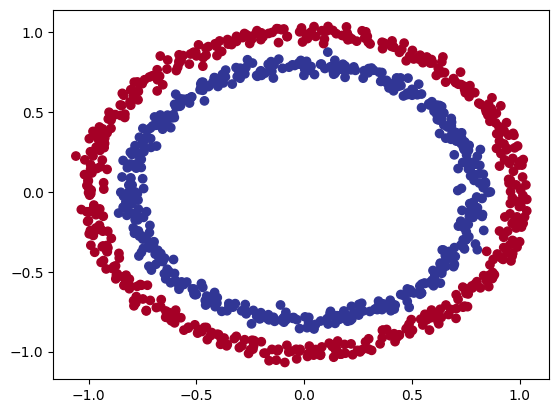

In [ ]:
plt.scatter(X[:,0] , X[:,1] , c = y , cmap = 'RdYlBu')

In [ ]:
X = torch.tensor(X , dtype = torch.float).to(device)
y = torch.tensor(y , dtype = torch.float).to(device)

Creating train and test splits

In [ ]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2 , random_state=42)
len(X_train),len(X_test),len(y_test),len(y_train)

(800, 200, 200, 800)

In [ ]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

(torch.Size([800, 2]),
 torch.Size([200, 2]),
 torch.Size([800]),
 torch.Size([200]))

In [ ]:
X_train = torch.tensor(X_train , dtype=torch.float32)
X_test = torch.tensor(X_test , dtype=torch.float32)
y_train = torch.tensor(y_train , dtype=torch.float32)
y_test = torch.tensor(y_test , dtype=torch.float32)

<ipython-input-10-2616631149>:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train , dtype=torch.float32)
<ipython-input-10-2616631149>:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(X_test , dtype=torch.float32)
<ipython-input-10-2616631149>:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train , dtype=torch.float32)
<ipython-input-10-2616631149>:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTens

Creating the model

In [ ]:
model = nn.Sequential(
    nn.Linear(in_features=2,out_features=10),
    nn.ReLU(),#Introducing NON-LINEARITY to the model
    nn.Linear(in_features=10,out_features=10),
    nn.ReLU(),#Or Model Activation functions for treating non linear data
    nn.Linear(in_features=10,out_features=1)
).to(device)

model

Sequential(
  (0): Linear(in_features=2, out_features=10, bias=True)
  (1): ReLU()
  (2): Linear(in_features=10, out_features=10, bias=True)
  (3): ReLU()
  (4): Linear(in_features=10, out_features=1, bias=True)
)

Loss function and Optimizer

In [ ]:
loss = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params = model.parameters(),lr = 0.1)

In [ ]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    acc = (correct / len(y_pred)) * 100
    return f'{acc}%'

Pre-Training Predictions

In [ ]:
with torch.inference_mode():
  Preds = model(X_test).squeeze()
  Pred = torch.round(torch.sigmoid(Preds))
Pred[:5] , y_test[:5]
accuracy_fn(y_test,Pred)

'51.0%'

In [ ]:
epochs = 10000

epoch_count = []
Training_loss = []
Testing_loss = []

for epoch in range(epochs):
  model.train()
  Train_Logits = model(X_train).squeeze()
  Train_Preds = torch.round(torch.sigmoid(Train_Logits))

  Train_Loss = loss(Train_Logits , y_train)
  Train_Acc = accuracy_fn(y_train , Train_Preds)

  optimizer.zero_grad()
  Train_Loss.backward()
  optimizer.step()

  model.eval()
  with torch.inference_mode():
    Test_Logits = model(X_test).squeeze()
    Test_Preds = torch.round(torch.sigmoid(Test_Logits))

    Test_Loss = loss(Test_Logits , y_test)
    Test_Acc = accuracy_fn(y_test , Test_Preds)

  if epoch%100==0:
    epoch_count.append(epoch)
    Training_loss.append(Train_Loss)
    Testing_loss.append(Test_Loss)
    print(f'Epoch : {epoch} / Training Loss and Accuracy : {Train_Loss} / {Train_Acc} / Testing Loss and Accuracy : {Test_Loss} / {Test_Acc}')


Epoch : 0 / Training Loss and Accuracy : 0.6969883441925049 / 50.875% / Testing Loss and Accuracy : 0.695066511631012 / 52.0%
Epoch : 100 / Training Loss and Accuracy : 0.689877450466156 / 55.125% / Testing Loss and Accuracy : 0.6908164024353027 / 53.5%
Epoch : 200 / Training Loss and Accuracy : 0.6860848665237427 / 55.75% / Testing Loss and Accuracy : 0.6880452036857605 / 53.0%
Epoch : 300 / Training Loss and Accuracy : 0.6819093227386475 / 56.00000000000001% / Testing Loss and Accuracy : 0.6849035620689392 / 52.5%
Epoch : 400 / Training Loss and Accuracy : 0.6762875318527222 / 56.25% / Testing Loss and Accuracy : 0.6808053255081177 / 53.0%
Epoch : 500 / Training Loss and Accuracy : 0.6680570244789124 / 61.75000000000001% / Testing Loss and Accuracy : 0.6749919056892395 / 58.5%
Epoch : 600 / Training Loss and Accuracy : 0.6549053192138672 / 67.625% / Testing Loss and Accuracy : 0.6658905148506165 / 62.0%
Epoch : 700 / Training Loss and Accuracy : 0.6336146593093872 / 71.625% / Testing

In [ ]:
with torch.inference_mode():
  Predictions = model(X_test).squeeze()
  Prediction = torch.round(torch.sigmoid(Predictions))
accuracy_fn(y_test , Prediction)

'100.0%'

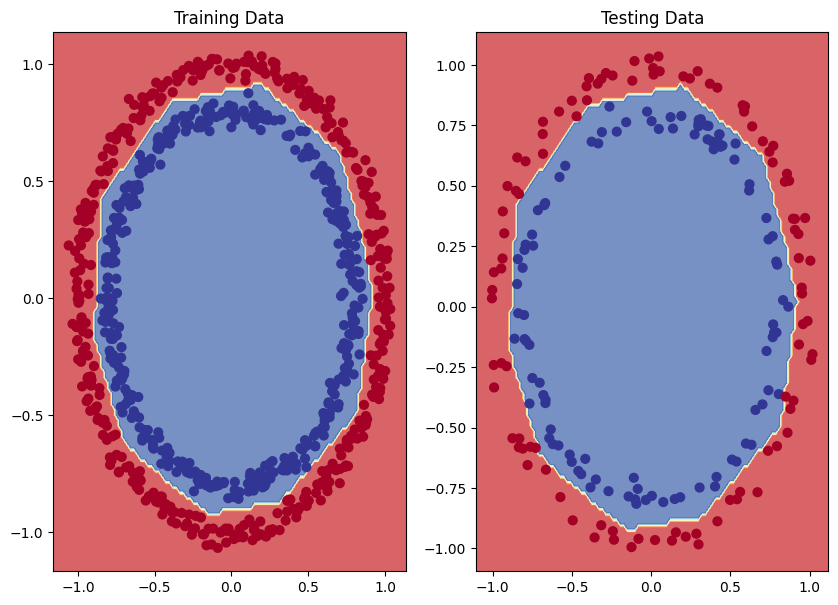

In [ ]:
plt.figure(figsize = (10,7))
plt.subplot(1,2,1)
plt.title('Training Data')
plot_decision_boundary(model , X_train , y_train)
plt.subplot(1,2,2)
plt.title('Testing Data')
plot_decision_boundary(model,X_test , y_test)

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
from sklearn.datasets import make_classification

x, Y = make_classification(n_samples=1000, n_features=20, n_informative=2,
                           n_redundant=2, n_classes=2, random_state=42)

In [ ]:
x = torch.from_numpy(x).to(torch.tensor(x))
Y = torch.from_numpy(Y).to(torch.tensor(Y))

In [ ]:
x_train , x_test ,  Y_train , Y_test = train_test_split(x,Y,train_size=0.8,random_state=42)
x_train = torch.tensor(x_train , dtype=torch.float32)
x_test = torch.tensor(x_test , dtype=torch.float32)
Y_train = torch.tensor(Y_train , dtype=torch.float32)
Y_test = torch.tensor(Y_test , dtype=torch.float32)

<ipython-input-31-523781011>:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_train = torch.tensor(x_train , dtype=torch.float32)
<ipython-input-31-523781011>:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_test = torch.tensor(x_test , dtype=torch.float32)
<ipython-input-31-523781011>:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y_train = torch.tensor(Y_train , dtype=torch.float32)
<ipython-input-31-523781011>:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.c

In [ ]:
s = pd.DataFrame({'X1' : x[:,0] , 'X2' : x[:,6], 'Y' : Y})
s

,X1,X2,Y
0,-0.669356,-1.251698,1
1,0.093372,1.263707,0
2,-0.905797,-0.064772,1
3,-0.585793,1.448820,1
4,1.146441,0.071254,0
...,...,...,...
995,0.519359,0.400236,0
996,-0.410935,-0.617285,1
997,-0.200135,-2.021994,1
998,0.039356,-0.802722,0


In [ ]:
s.Y.value_counts()

,count
Y,
1,500
0,500


In [ ]:
model_01 = nn.Sequential(
    nn.Linear(in_features=20 , out_features=32),
    nn.ReLU(),
    nn.Linear(in_features=32 , out_features=16),
    nn.ReLU(),
    nn.Linear(in_features=16 , out_features=1)
)

In [ ]:
model_01.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.1710,  0.1856, -0.0524,  0.2054, -0.0490,  0.0451, -0.1089,  0.1313,
                        0.1971, -0.1640,  0.1944,  0.0419,  0.1652,  0.0303,  0.1078, -0.0316,
                        0.1724,  0.0331, -0.1044,  0.0570],
                      [-0.1030, -0.0262, -0.0908,  0.1483, -0.1765, -0.1031, -0.0631, -0.1344,
                        0.0211, -0.2209,  0.2019, -0.1899,  0.1726,  0.0372, -0.0726,  0.1382,
                        0.0348,  0.1807,  0.0244, -0.0705],
                      [ 0.0601, -0.0606,  0.0941,  0.1996,  0.1293, -0.0978,  0.1291,  0.0400,
                        0.1136, -0.1363, -0.2214, -0.0864, -0.1715,  0.1835,  0.0644,  0.0926,
                        0.0707, -0.0039,  0.1750, -0.1589],
                      [ 0.0141, -0.1526,  0.0689, -0.0770,  0.0685, -0.0466,  0.1855, -0.1325,
                       -0.1334, -0.1334,  0.2011,  0.0745,  0.2152, -0.1845, -0.2218, -0.1749,
                       -0.1504,  0

In [ ]:
Loss = nn.BCELoss()
Optim = torch.optim.SGD(params = model_01.parameters() , lr = 0.001)

In [ ]:
# with torch.inference_mode():
#   PtP = torch.round(torch.sigmoid(model_01(x_test)))
# PtP[:10].squeeze() , Y_test[:10]

In [ ]:
# PtP.shape , Y_test.shape

In [ ]:
# accuracy_fn(y_true=Y_test , y_pred=PtP.squeeze())

In [ ]:
torch.cuda.manual_seed(42)
torch.manual_seed(42)
Epochs = 1000
for epocH in range(Epochs):
  model_01.train()
  Train_L = model_01(x_train).squeeze()
  Train_P = torch.round(torch.sigmoid(Train_L))

  Train_Lo = Loss(Train_P , Y_train)
  Train_Accuracy = accuracy_fn(Y_train , Train_P)

  Optim.zero_grad()
  Train_Lo.backward()
  Optim.step()

  model_01.eval()
  with torch.inference_mode():
    Test_L = model_01(x_test).squeeze()
    Test_P = torch.round(torch.sigmoid(Test_L))

    Test_Lo = Loss(Test_P , Y_test)
    Test_Accuracy = accuracy_fn(Y_test , Test_P)

  if epocH%100==0:
    print(f'Epoch == {epocH} , Training Loss = {Train_Lo} ,Train_Accuracy = {Train_Accuracy} , Test_Loss = {Test_Lo} , Test_Accuracy = {Test_Accuracy}')

Epoch == 0 , Training Loss = 51.0 ,Train_Accuracy = 49.0% , Test_Loss = 45.5 , Test_Accuracy = 54.50000000000001%
Epoch == 100 , Training Loss = 51.0 ,Train_Accuracy = 49.0% , Test_Loss = 45.5 , Test_Accuracy = 54.50000000000001%
Epoch == 200 , Training Loss = 51.0 ,Train_Accuracy = 49.0% , Test_Loss = 45.5 , Test_Accuracy = 54.50000000000001%
Epoch == 300 , Training Loss = 51.0 ,Train_Accuracy = 49.0% , Test_Loss = 45.5 , Test_Accuracy = 54.50000000000001%
Epoch == 400 , Training Loss = 51.0 ,Train_Accuracy = 49.0% , Test_Loss = 45.5 , Test_Accuracy = 54.50000000000001%
Epoch == 500 , Training Loss = 51.0 ,Train_Accuracy = 49.0% , Test_Loss = 45.5 , Test_Accuracy = 54.50000000000001%
Epoch == 600 , Training Loss = 51.0 ,Train_Accuracy = 49.0% , Test_Loss = 45.5 , Test_Accuracy = 54.50000000000001%
Epoch == 700 , Training Loss = 51.0 ,Train_Accuracy = 49.0% , Test_Loss = 45.5 , Test_Accuracy = 54.50000000000001%
Epoch == 800 , Training Loss = 51.0 ,Train_Accuracy = 49.0% , Test_Loss = 

In [ ]:
model_01.eval()
with torch.inference_mode():
  Test = model_01(x_test).squeeze()
  Test_P = torch.round(torch.sigmoid(Test_L))

  Test_Lo = Loss(Test_P , Y_test)
  Test_Accuracy = accuracy_fn(Y_test , Test_P)

In [ ]:
Test_Accuracy

'54.50000000000001%'

In [ ]:
Train_P

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 

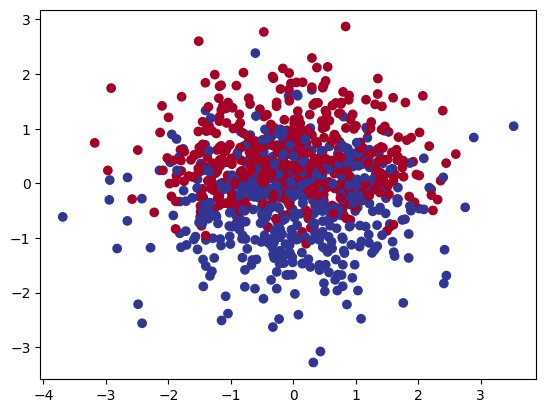

In [ ]:
plt.scatter(x[:,0] , x[:,1] , c = Y , cmap = 'RdYlBu' )